In [1]:
import pandas as pd

top = pd.read_csv(r"C:\Users\Jiyoon\billboard-project\data\processed\top_per_year.csv")
enriched = pd.read_csv(r"C:\Users\Jiyoon\billboard-project\data\raw\Hot 100 Audio Features.csv")
# replace filename.csv with your actual enriched dataset filename

top['song_clean'] = top['song'].str.lower().str.strip()
top['artist_clean'] = top['artist'].str.lower().str.strip()
enriched['song_clean'] = enriched['Song'].str.lower().str.strip()
enriched['artist_clean'] = enriched['Performer'].str.lower().str.strip()

enriched_dedup = enriched.drop_duplicates(subset=['song_clean', 'artist_clean'], keep='first')

merged = top.merge(
    enriched_dedup[['song_clean', 'artist_clean', 'danceability', 'energy', 
               'valence', 'tempo', 'acousticness', 'speechiness',
               'instrumentalness', 'liveness', 'loudness']],
    on=['song_clean', 'artist_clean'],
    how='left'
)

print("Merged shape:", merged.shape)

Merged shape: (64, 16)


In [2]:
merged.to_csv(r"C:\Users\Jiyoon\billboard-project\data\processed\merged.csv", index=False)
print("Saved!")

Saved!


In [3]:
merged[merged['year'] >= 2019][['year','song','artist','danceability','energy','valence']]

,year,song,artist,danceability,energy,valence
61,2019,Old Town Road,Lil Nas X Featuring Billy Ray Cyrus,0.878,0.619,0.639
62,2020,The Box,Roddy Ricch,0.896,0.586,0.642
63,2021,Butter,BTS,NaN,NaN,NaN


In [4]:
print("Merged shape:", merged.shape)
print("Rows with audio features:", merged['energy'].notna().sum())
print("Rows missing:", merged['energy'].isna().sum())

Merged shape: (64, 16)
Rows with audio features: 55
Rows missing: 9


In [5]:
decade_avg = merged.groupby('decade')[
    ['tempo','energy','valence','danceability','acousticness','speechiness']
].mean().round(3)

decade_avg

,tempo,energy,valence,danceability,acousticness,speechiness
decade,,,,,,
1950,93.968,0.402,0.559,0.466,0.399,0.069
1960,112.773,0.559,0.706,0.484,0.485,0.038
1970,112.585,0.478,0.573,0.493,0.532,0.037
1980,117.326,0.680,0.675,0.632,0.251,0.036
1990,110.290,0.575,0.476,0.554,0.275,0.032
2000,118.272,0.697,0.676,0.783,0.099,0.119
2010,125.486,0.644,0.714,0.768,0.111,0.089
2020,116.971,0.586,0.642,0.896,0.104,0.056


In [6]:
missing_songs = merged[merged['energy'].isna()][['year','song','artist']]
print(f"Total missing: {len(missing_songs)}")
missing_songs

Total missing: 9


,year,song,artist
8,1966,The Ballad Of The Green Berets,SSgt Barry Sadler
11,1969,Aquarius/Let The Sunshine In (The Flesh Failures),The 5th Dimension
17,1975,Love Will Keep Us Together,The Captain & Tennille
27,1985,We Are The World,USA For Africa
34,1992,"End Of The Road (From ""Boomerang"")",Boyz II Men
38,1996,Macarena (Bayside Boys Mix),Los Del Rio
39,1997,Candle In The Wind 1997/Something About The Wa...,Elton John
52,2010,TiK ToK,Ke$ha
63,2021,Butter,BTS


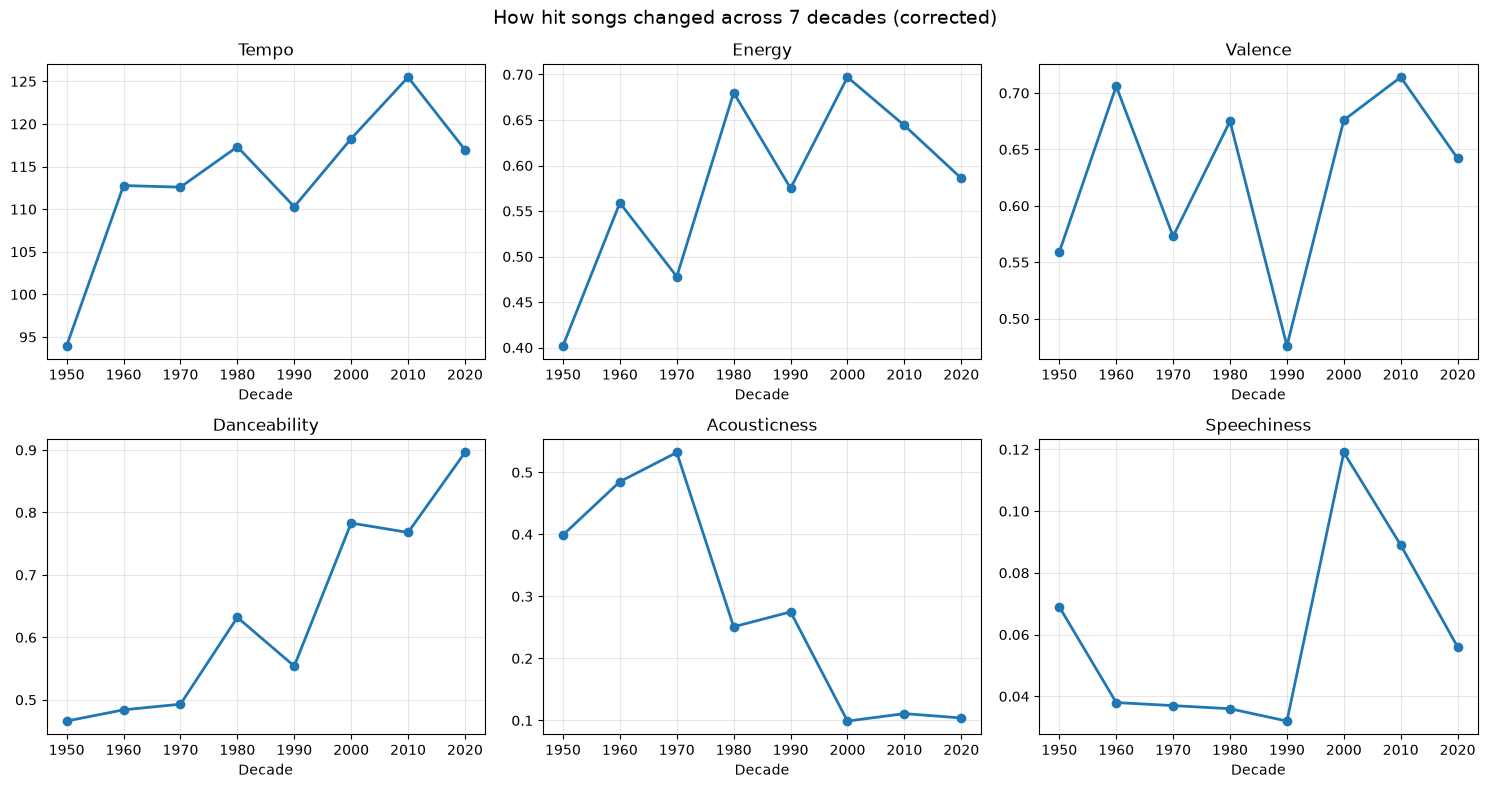

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['tempo','energy','valence','danceability','acousticness','speechiness']

for ax, feature in zip(axes.flat, features):
    ax.plot(decade_avg.index, decade_avg[feature], marker='o', linewidth=2)
    ax.set_title(feature.capitalize())
    ax.set_xlabel('Decade')
    ax.grid(alpha=0.3)

plt.suptitle('How hit songs changed across 7 decades (corrected)', fontsize=14)
plt.tight_layout()
plt.savefig(r"C:\Users\Jiyoon\billboard-project\visuals\decade_trends.png", dpi=150)
plt.show()

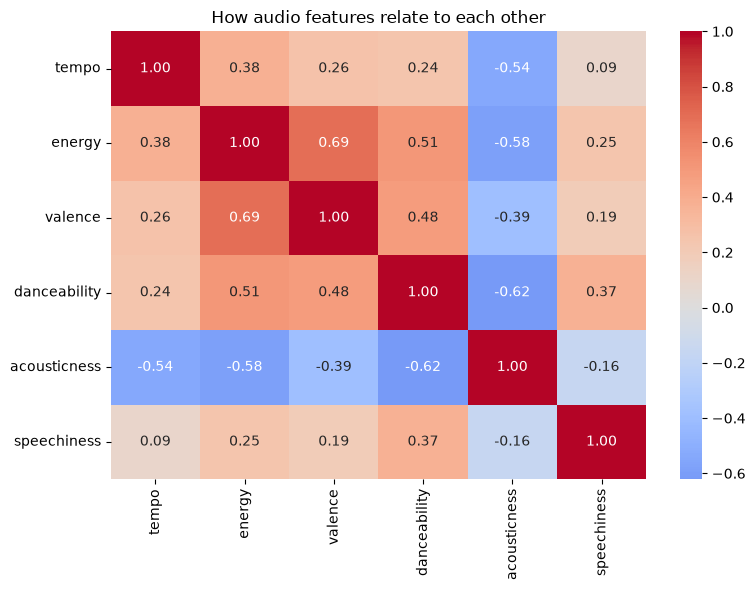

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['tempo','energy','valence','danceability','acousticness','speechiness']
corr = merged[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('How audio features relate to each other')
plt.tight_layout()
plt.savefig(r"C:\Users\Jiyoon\billboard-project\visuals\correlation_heatmap.png", dpi=150)
plt.show()

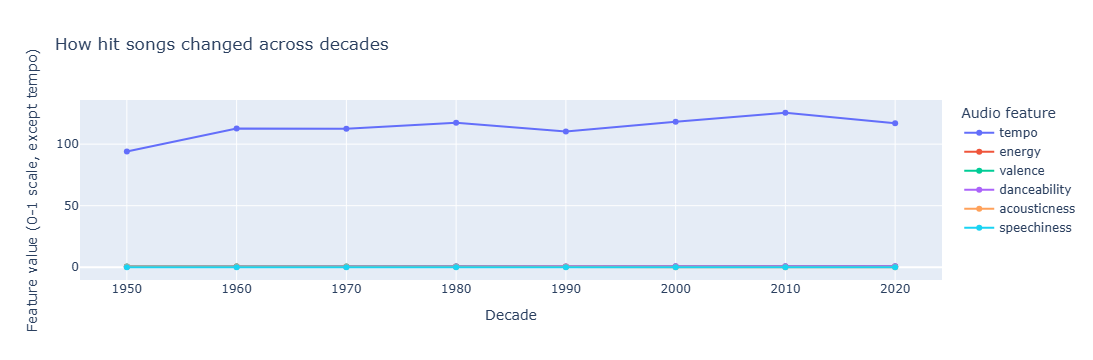

In [9]:
import plotly.express as px

decade_long = decade_avg.reset_index().melt(
    id_vars='decade', var_name='feature', value_name='score'
)

fig = px.line(
    decade_long,
    x='decade', y='score', color='feature',
    markers=True,
    title='How hit songs changed across decades'
)
fig.update_layout(
    xaxis_title='Decade', yaxis_title='Feature value (0-1 scale, except tempo)',
    legend_title='Audio feature'
)
fig.write_html(r"C:\Users\Jiyoon\billboard-project\visuals\animated_trends.html")
fig.show()

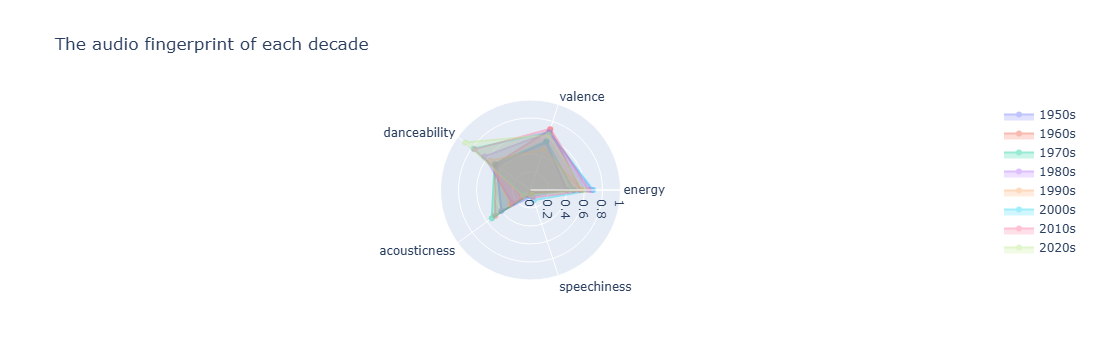

In [10]:
import plotly.graph_objects as go

features_radar = ['energy','valence','danceability','acousticness','speechiness']

fig = go.Figure()

for decade, row in decade_avg.iterrows():
    vals = row[features_radar].tolist()
    fig.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],  # repeat first value to close the shape
        theta=features_radar + [features_radar[0]],
        name=str(int(decade)) + 's',
        fill='toself',
        opacity=0.4
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(range=[0,1], visible=True)),
    title='The audio fingerprint of each decade',
    showlegend=True
)

fig.write_html(r"C:\Users\Jiyoon\billboard-project\visuals\radar_chart.html")
fig.show()